# Experimento 01

## Espectrogramas de más resolución

In [1]:
%%capture
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from signal_grad_cam.pytorch_cam_builder import TorchCamBuilder

I0000 00:00:1780886853.377216    1348 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780886854.059063    1348 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780886855.536621    1348 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780886855.540629    1348 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

# Cambios MELs
SAMPLE_RATE = 16000
N_MELS =128
N_FFT = int(768)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(100)

In [3]:
final_path = '01-experimento_01/final'
checkpoints_path = '01-experimento_01/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/01-experimento_01')
batch_size = 224
epochs = 10

In [4]:
%%capture
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,
        with_log = True,
        device = DEVICE,
        mode = "training")

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE)
# Modelo
model = AudioResNetModel(dims=2, num_classes=NUM_CLASSES).get_model()
model.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

Antes de entrenar vamos a visualizar algún ejemplo de cómo van a quedar los espectrogramas:

In [6]:
# Visualización inicial espectrogramas nueva configuración
few_samples_dataset = GSC(file_list=train_list[:6], labels=train_labels[:6])
few_samples_loader = DataLoader(few_samples_dataset, batch_size=6, shuffle=True, collate_fn=prepare_batch, num_workers=4)
file_names = [Path(p).stem for p in train_list[:6]]

In [7]:
for batch_waves, _, _ in few_samples_loader:
    with torch.no_grad():
        mels = preprocessor_test.transform_batch(batch_waves)
        persister.save_spectrogram_images(specs = mels, file_names = file_names)

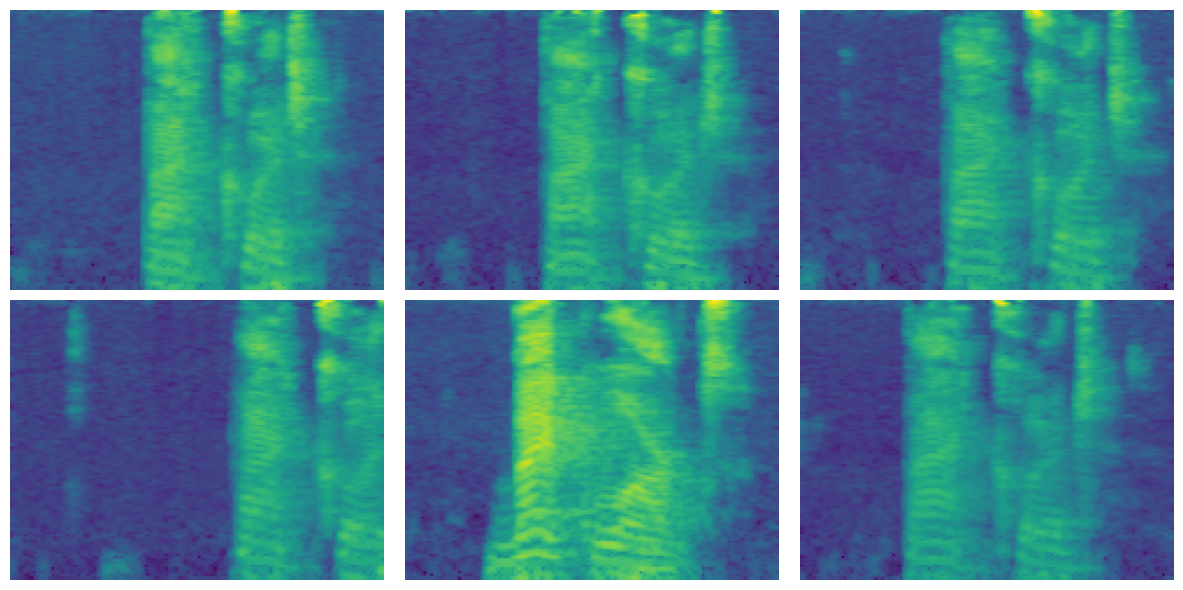

In [8]:
images_to_show = sorted(Path(f"{xai_path}/espectrogramas").glob("*.png"))
show_image_grid(images_to_show, rows=2, figsize=(12,6))

Se observa que la resolución frecuencial ha mejorado de manera evidente y se aprecia la distribución espectral de los formantes de las vocales si bien los espectrogramas ocupan mucho más en memoria. Por tanto, reduciremos el BATCH_SIZE a 224 muestras, que son las que puede albergar la RAM de la GPU. Haremos un entrenamiento corto para evaluar la procedencia de incluir este cambio en la pipeline.

In [9]:
trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=10, resume_from=f"{final_path}/final_model.pt")                        
trainer.fit(resume=True)

Cargado desde 01-experimento_01-test2/final/final_model.pt. Comenzamos en epoch 6
Cargado desde 01-experimento_01-test2/final/final_model.pt. Comenzamos en epoch 6


Epoch::   0%|          | 0/5 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/386 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 6/10
  Train - Pérdida: 0.1278, Accuracy: 0.9599, F1-score: 0.9571
  Val   - Pérdida: 0.3005, Accuracy: 0.9142, F1-score: 0.9048


...

Batches validación:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 9/10
  Train - Pérdida: 0.0647, Accuracy: 0.9800, F1-score: 0.9782
  Val   - Pérdida: 0.2678, Accuracy: 0.9345, F1-score: 0.9276


Batches entrenamiento:   0%|          | 0/386 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 10/10
  Train - Pérdida: 0.0526, Accuracy: 0.9833, F1-score: 0.9819
  Val   - Pérdida: 0.2749, Accuracy: 0.9325, F1-score: 0.9269


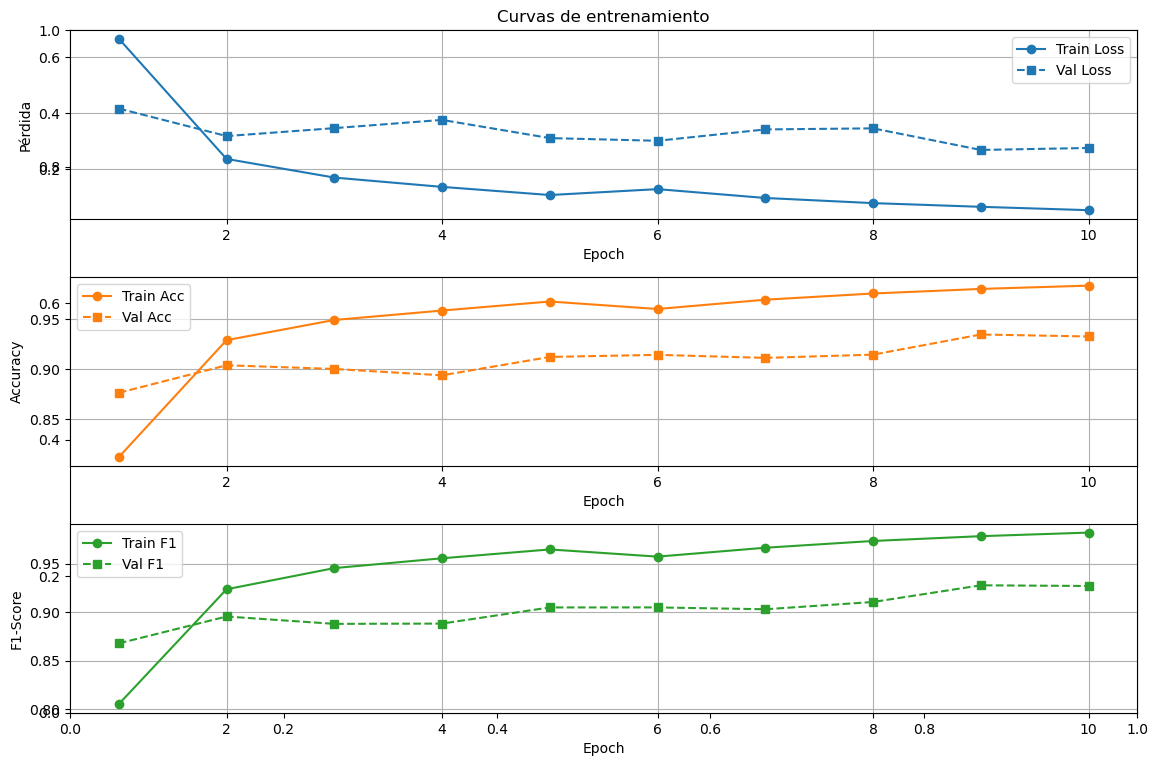

In [11]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

**Análisis del entrenamiento**

Vemos en la evolución de la métrica de validación que las curvas de entrenamiento mejoran ligeramente con respecto a la línea de base, y el modelo que parece tener mejor métrica en este caso es el final, sobre el que visualizaremos los datos.

In [12]:
# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/56 [00:00<?, ?it/s]

Pérdida: 0.7010920524140923 Accuracy: 0.9134379134379135 F1-Score: 0.9079481433622509


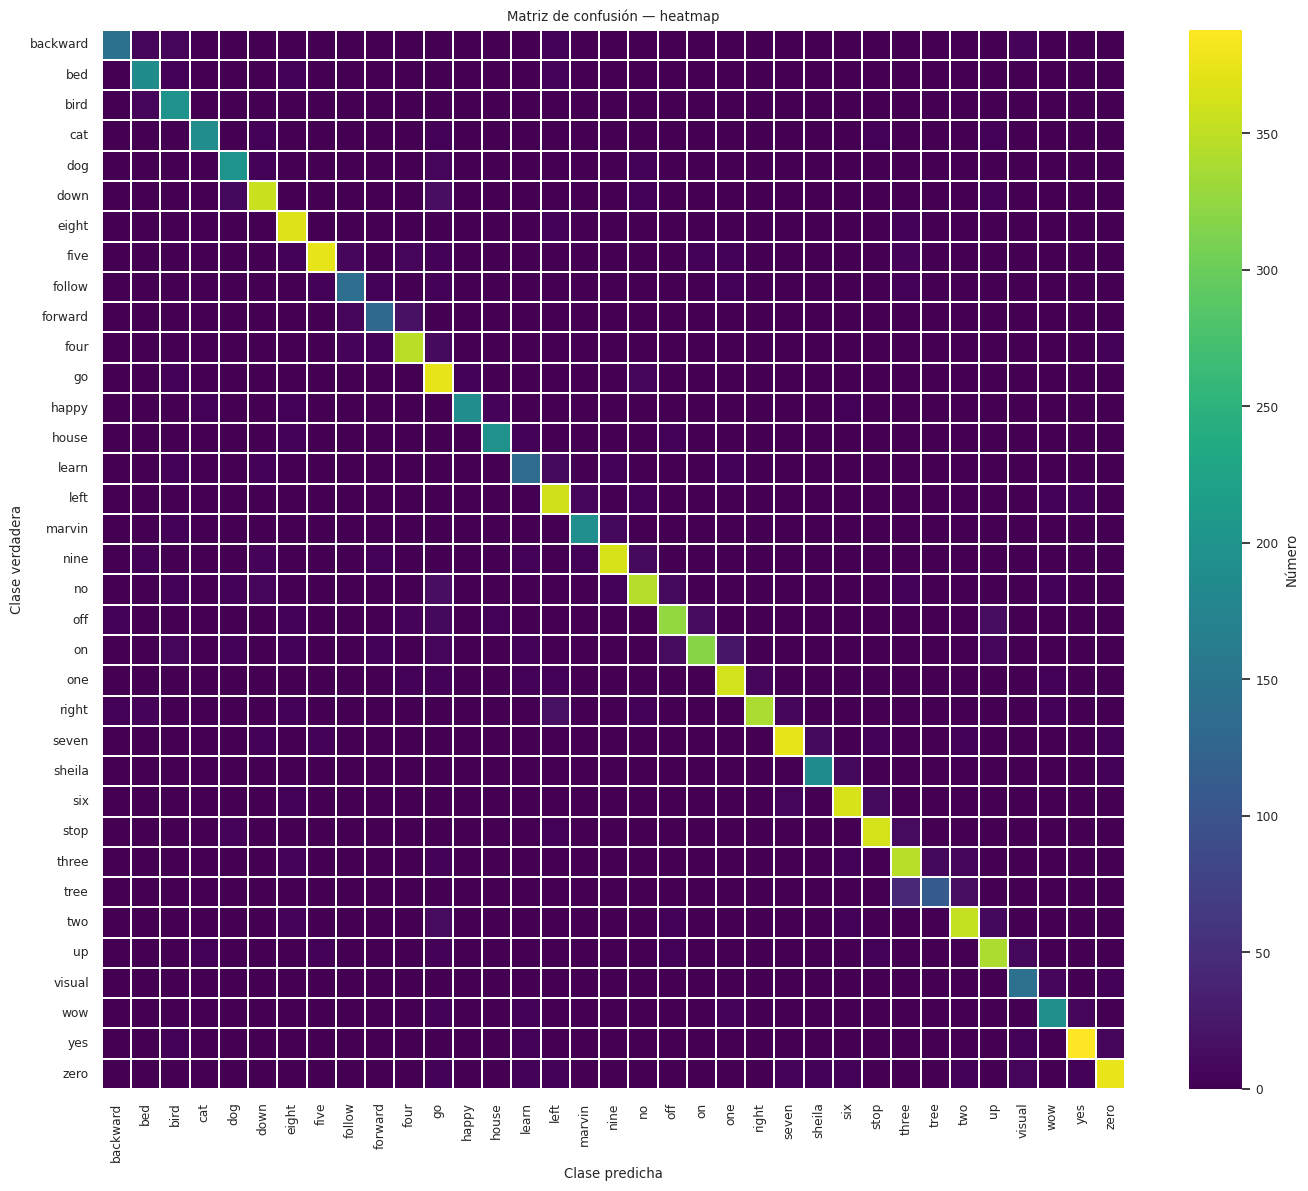

In [13]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize = (14,12))
sb.set(font_scale = 0.8)
ax = sb.heatmap(confusion_matrix,
                annot=False,
                fmt = ".2f",
                cmap = "viridis",
                cbar_kws = {"label": "Número"},
                xticklabels = label_names,
                yticklabels = label_names,
                linewidths = 0.3,
                linecolor = "white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión — heatmap")
plt.tight_layout()
plt.show()
plt.rcdefaults()

A primera vista, las falsas clasificaciones estánbastante repartidas. Tenemos falsas clasificaciones go/off, up/off y, en menor medida go/down.

In [14]:
print("Accuracy:", accuracy, "Precission:", precission, "Recall:", recall, "Pérdida media:", avg_loss, "F1-score:", f1)

Accuracy: 0.9134379134379135 Precission: 0.9126072291432772 Recall: 0.906553901525502 Pérdida media: 0.7010920524140923 F1-score: 0.9079481433622509


In [15]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [16]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "Grad-CAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

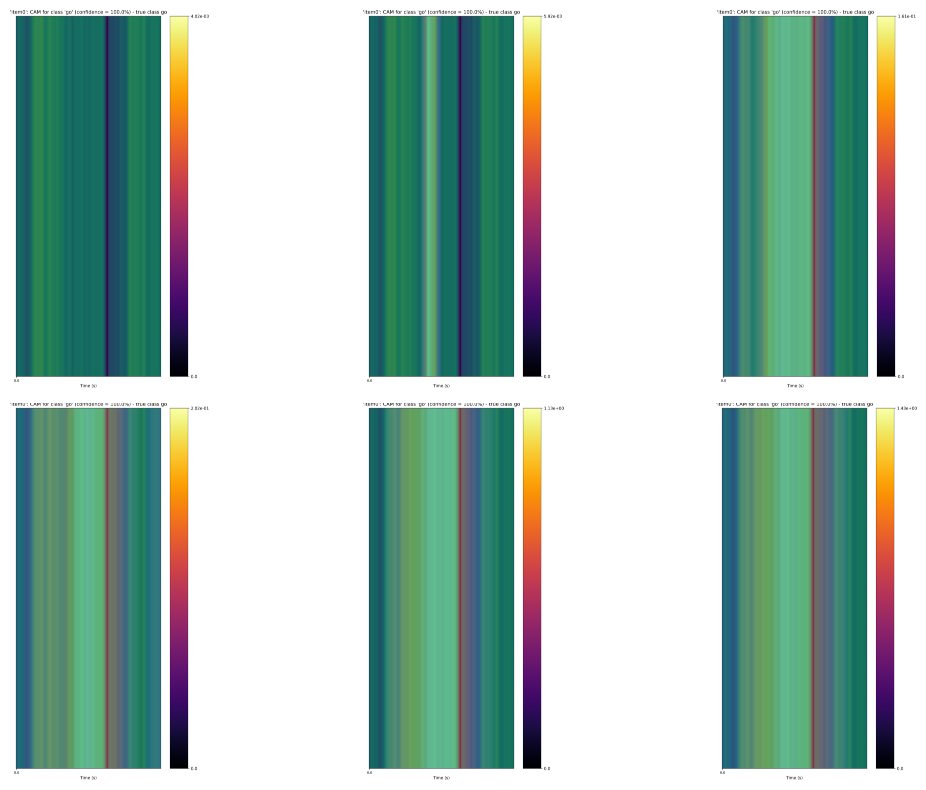

In [17]:
## Visualizamos muestra de capas
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*Grad*.png"))
show_image_grid(images_to_show)

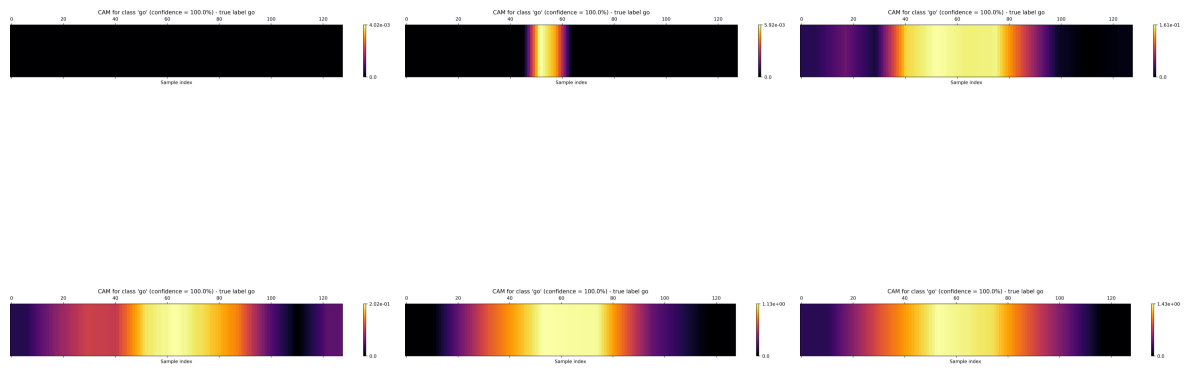

In [18]:
## Visualizamos sólo las CAMs
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/0-2/item0/").glob("*Grad-CAM*11.png"))
show_image_grid(images_to_show)

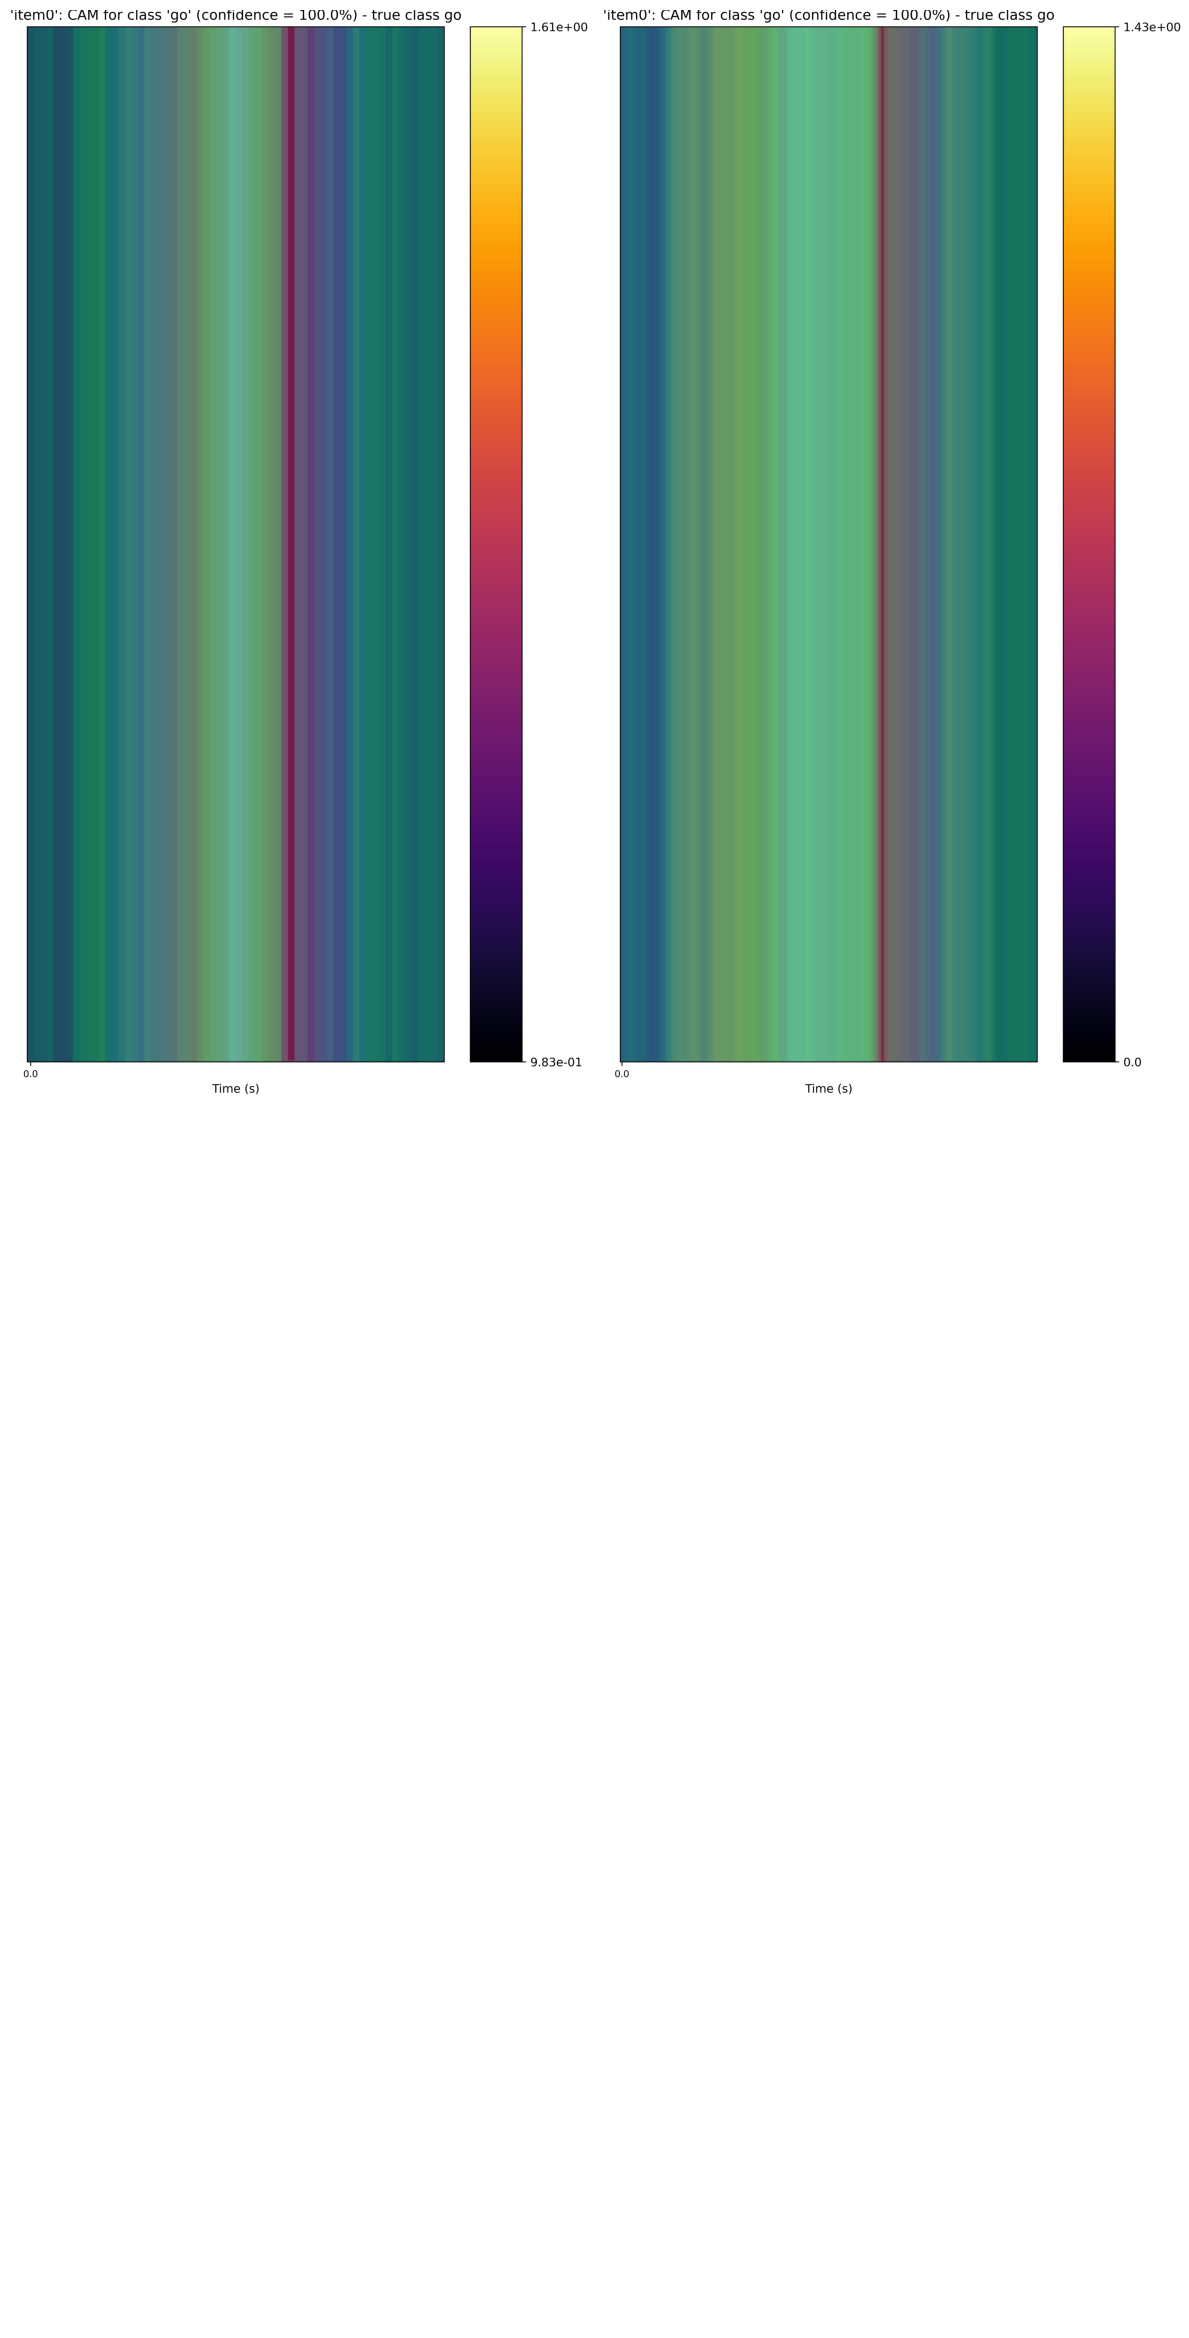

In [19]:
# CAM "GO"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

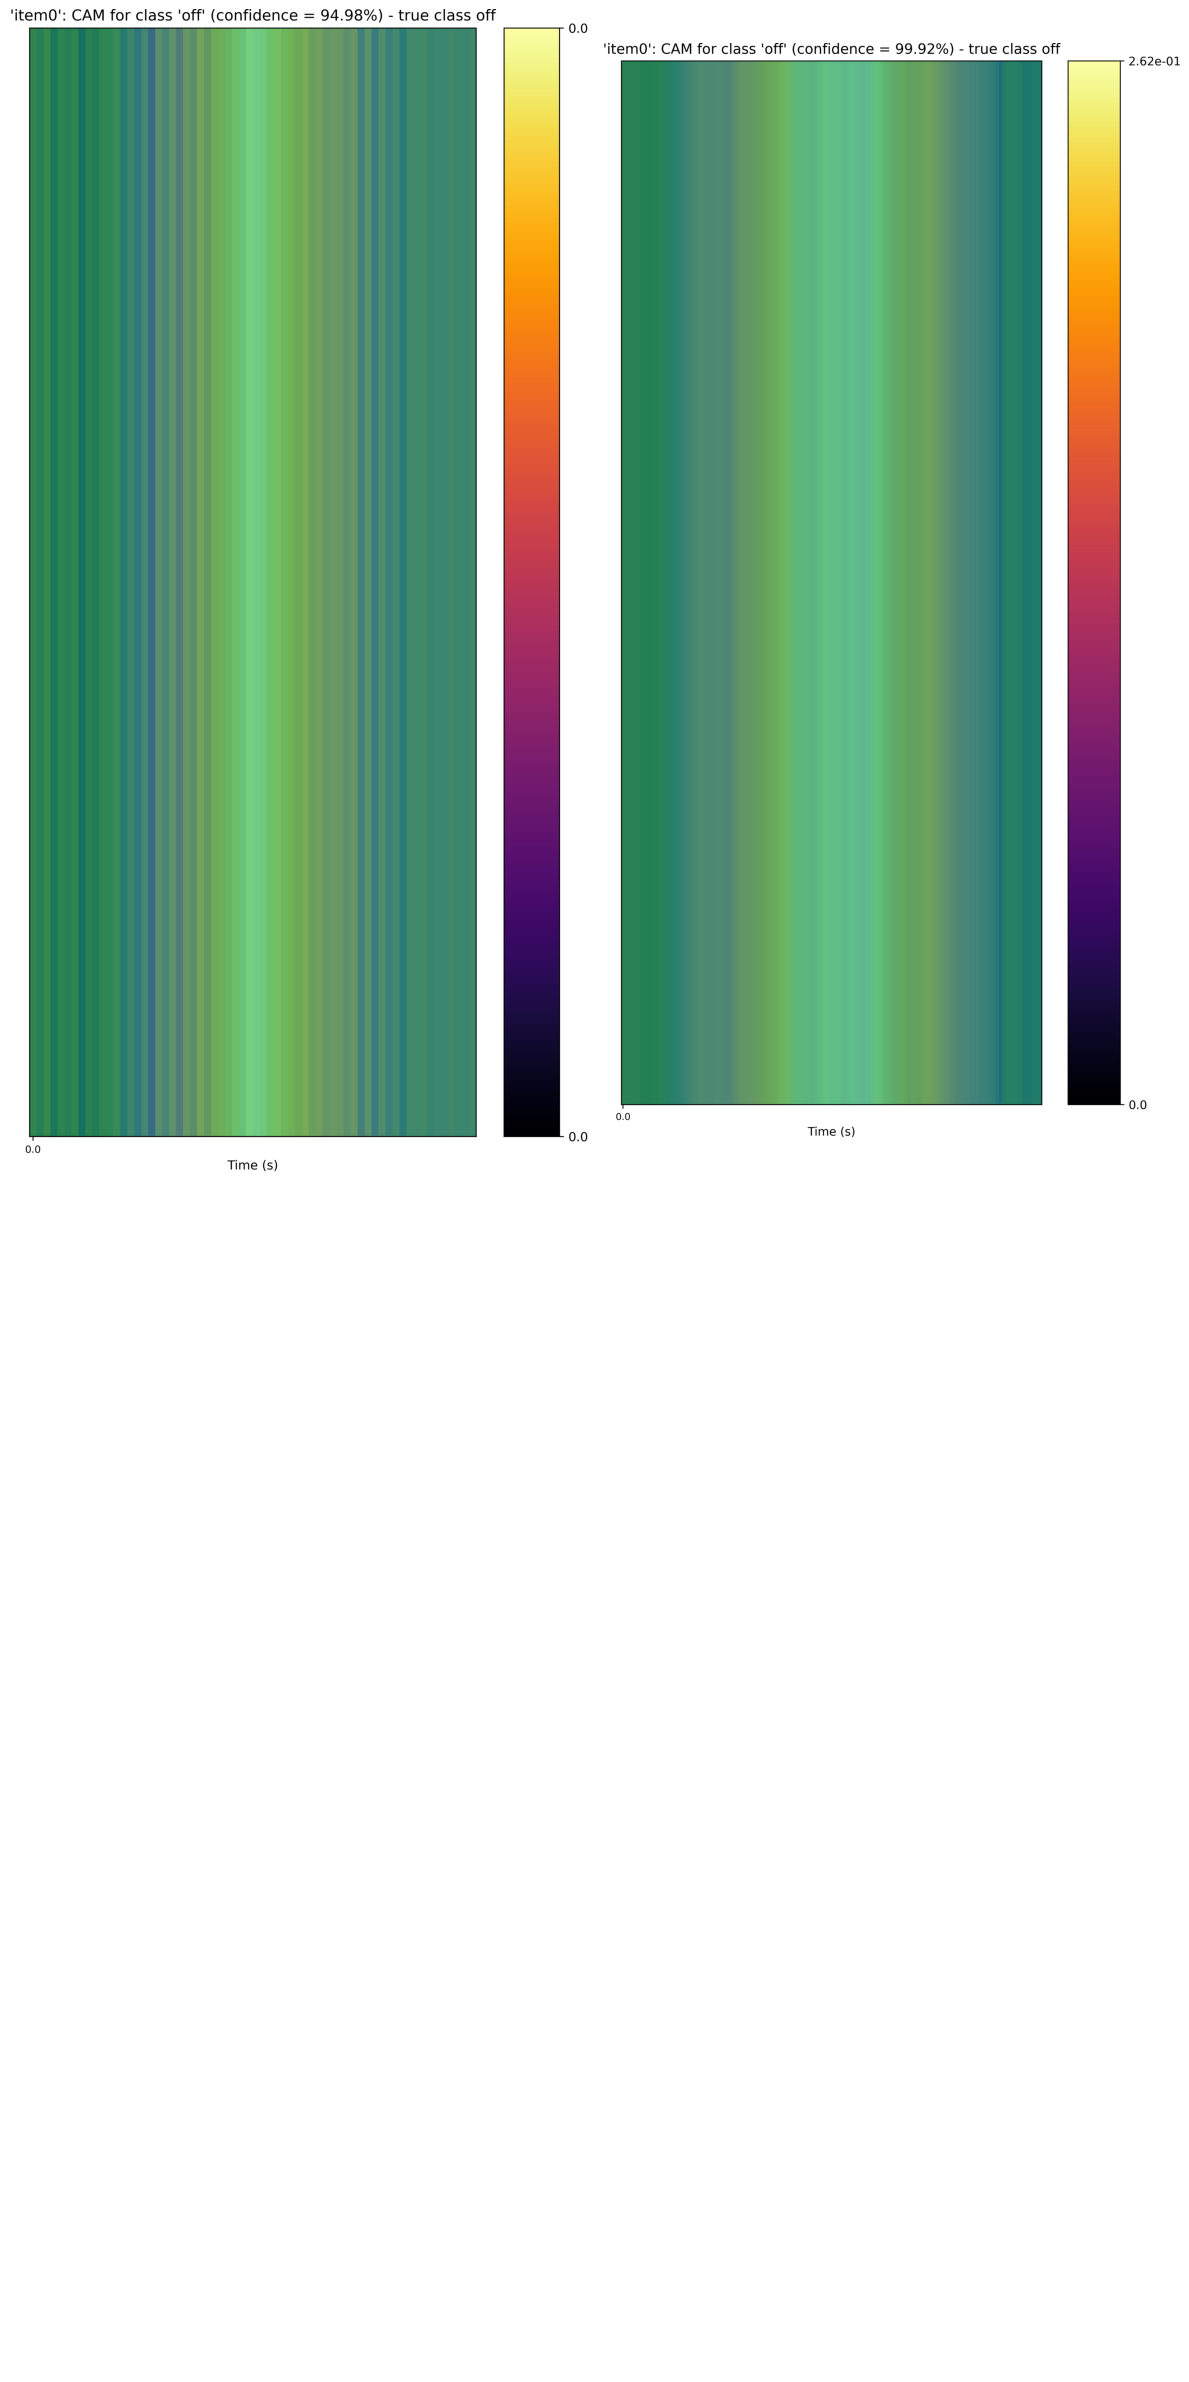

In [20]:
# CAM "OFF"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

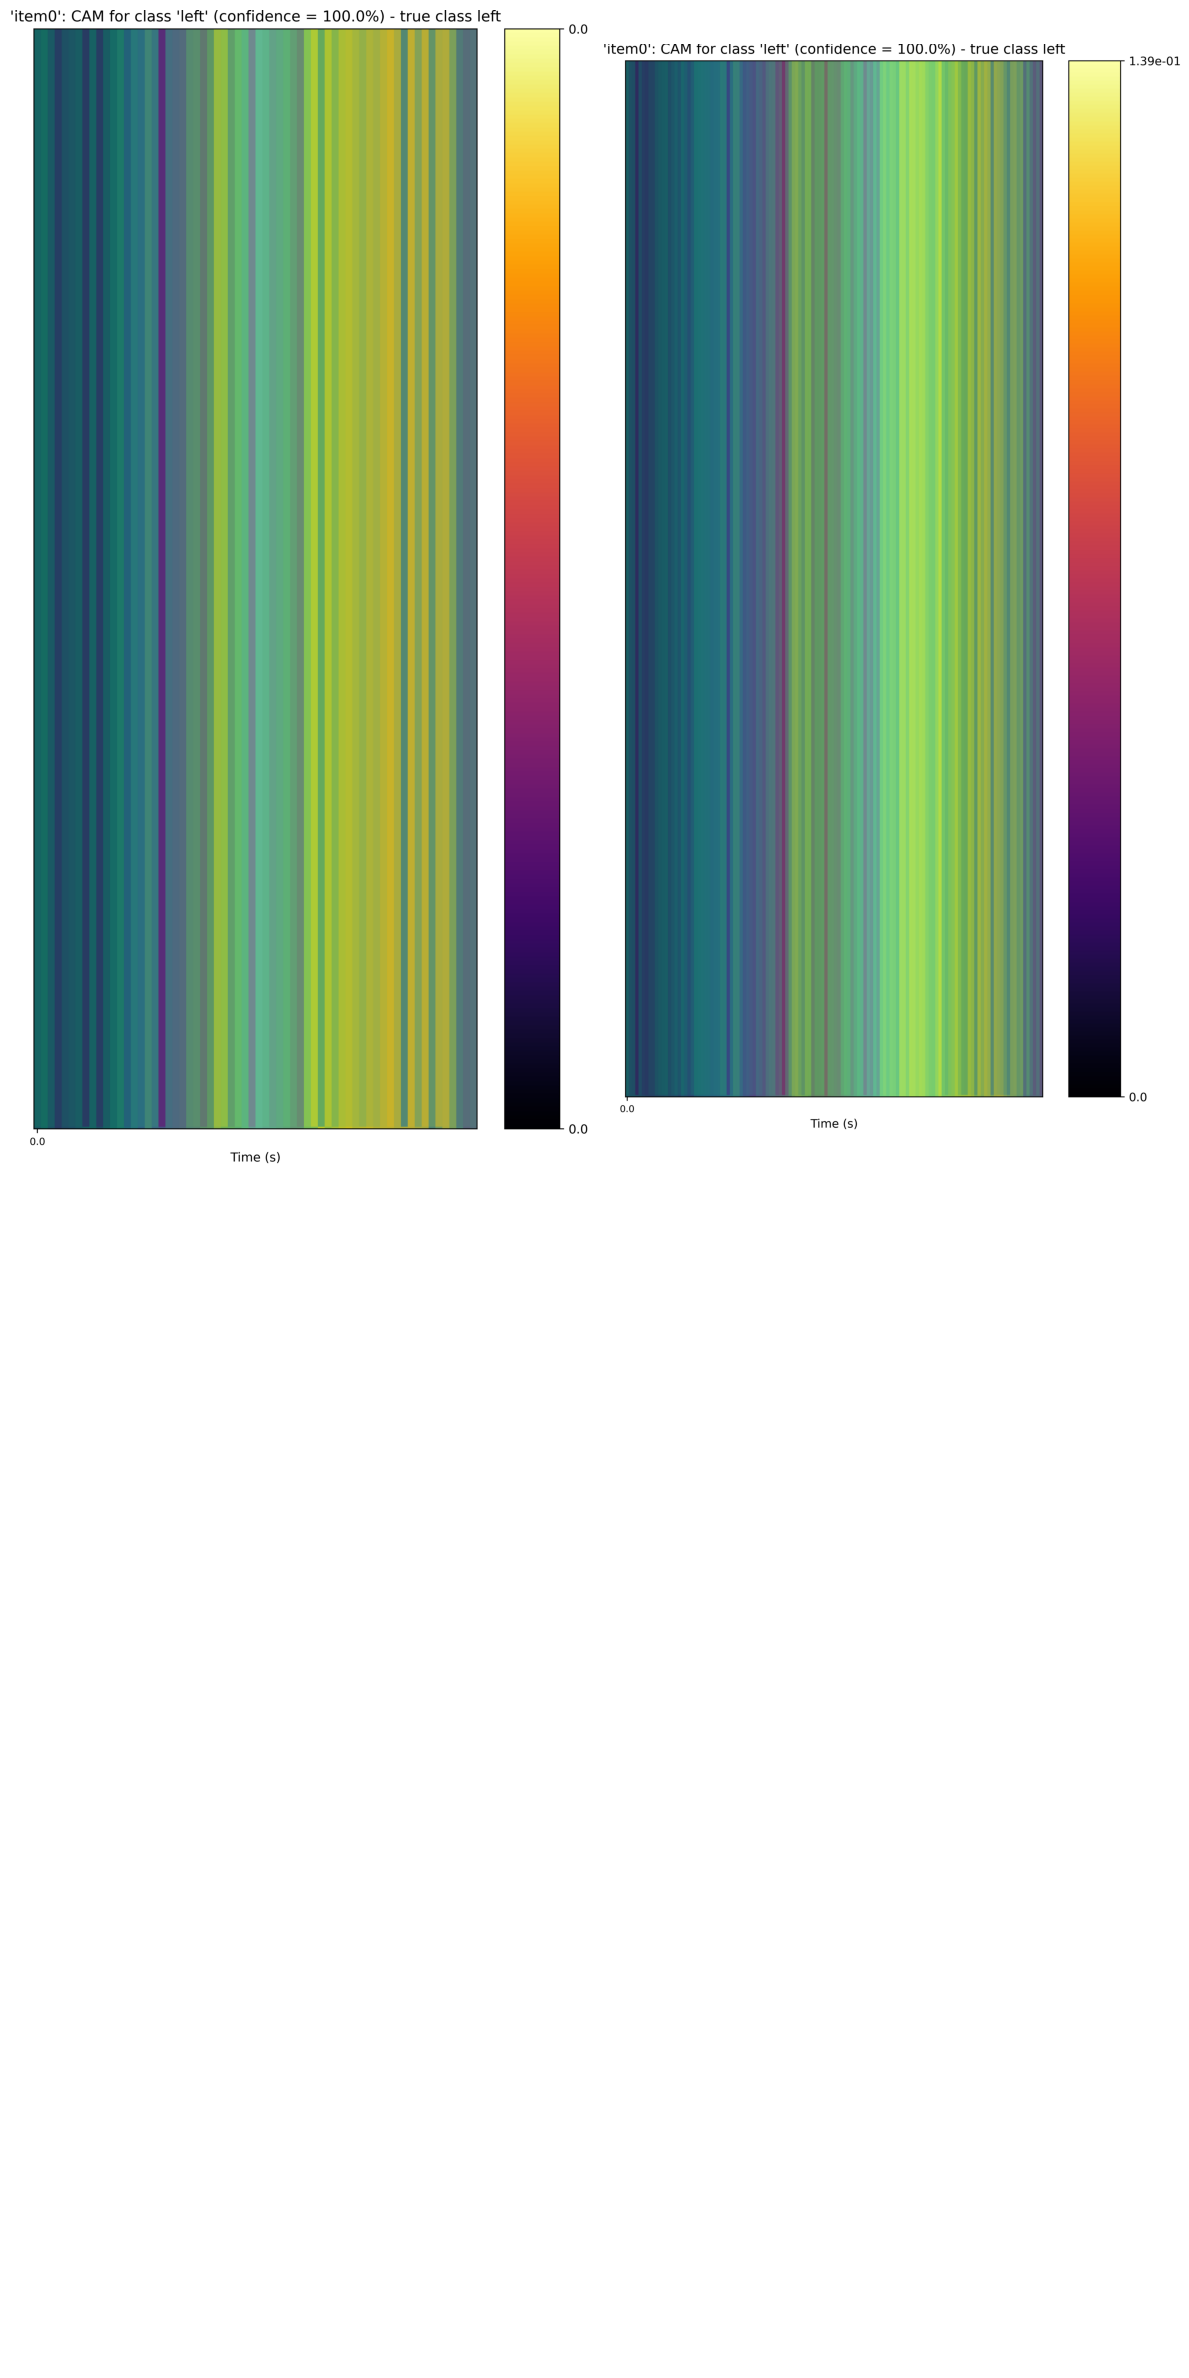

In [21]:
# CAM "LEFT"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

El modelo se adapta bien a estas dimensiones y las métricas son mejores. Se aprecia en los CAMs una mayor resolución, pero no se discrimina en el eje frecuencial específicamente, sino como conribución a las ventanas temporales. Observamos ahora HiResCAM:

In [22]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "HiResCAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

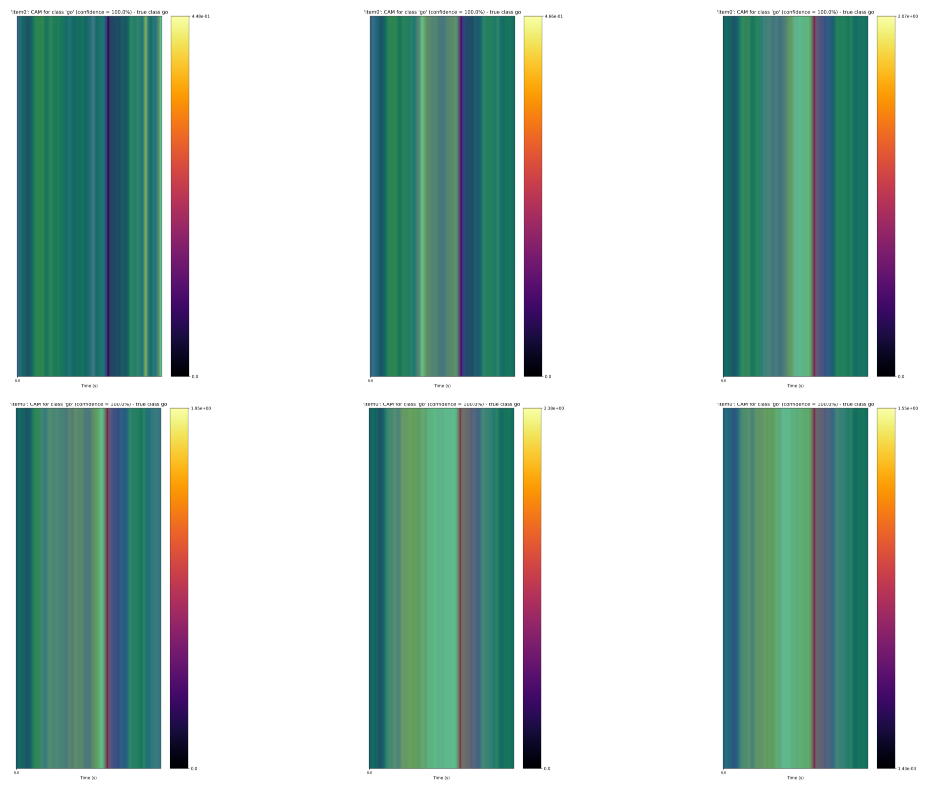

In [23]:
## Visualizamos
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*HiRes*.png"))
show_image_grid(images_to_show)

Se observa que en las capas en las que aparecen gradientes aún son de color sólido en el eje frecuencial. Vamos a tratar de adaptar el modelo en la dimensión frecuencial en el EXPERIMENTO 2.

Finalmente, vamos a estimar el coste de entrenamiento a partir del tiempo medio por epoch.

In [24]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
print(avg_etime)

156.118861746788


El coste de entrenamiento se multiplica por 2.77 con respecto de la línea de base.